<a href="https://colab.research.google.com/github/iqlore-collab/API-PROJECTS/blob/main/weather_openweather_api_github_enhanced_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Data Collection and Analysis with OpenWeather API

This notebook collects weather forecast data for selected cities using the OpenWeather API.

It is GitHub- and Colab-ready:

- no API keys are hardcoded,
- no local MySQL database is required,
- API calls use retry logic,
- data is exported to CSV,
- a `metadata.json` file documents the run,
- basic weather analysis and visualizations are included.

The notebook is designed as a clean data engineering / API portfolio project.


## 1. Project workflow

The notebook performs the following steps:

1. Configure cities, country, units, and output folder.
2. Convert city names to latitude and longitude.
3. Download 5-day weather forecast data.
4. Flatten forecast JSON into pandas DataFrames.
5. Create current-nearest and daily weather summaries.
6. Visualize temperature, wind, humidity, and weather conditions.
7. Export CSV files and metadata.


## 2. Setup

In [1]:
import json
import time
from datetime import datetime
from getpass import getpass
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt


## 3. Configuration

In [2]:
OPENWEATHER_API_KEY = getpass("Paste your OpenWeather API key: ")

BASE_GEO_URL = "https://api.openweathermap.org/geo/1.0/direct"
BASE_FORECAST_URL = "https://api.openweathermap.org/data/2.5/forecast"

CITIES = [
    "Berlin",
    "Hamburg",
    "Munich",
    "Cologne",
    "Frankfurt",
]

COUNTRY_CODE = "DE"
UNITS = "metric"
LANGUAGE = "en"

OUTPUT_DIR = Path("outputs_weather")
OUTPUT_DIR.mkdir(exist_ok=True)

REQUEST_SLEEP_SECONDS = 0.5
MAX_RETRIES = 3
TIMEOUT_SECONDS = 30


Paste your OpenWeather API key: ··········


## 4. API request helper with retry logic

In [3]:
def safe_get_json(
    url: str,
    params: dict | None = None,
    timeout: int = TIMEOUT_SECONDS,
    max_retries: int = MAX_RETRIES,
    sleep_seconds: float = REQUEST_SLEEP_SECONDS,
):
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()

        except requests.exceptions.HTTPError as error:
            status_code = getattr(error.response, "status_code", None)
            print(f"HTTP error on attempt {attempt}/{max_retries}: {error}")

            if status_code in [429, 500, 502, 503, 504] and attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            try:
                print("Response preview:", response.text[:500])
            except Exception:
                pass
            return None

        except requests.exceptions.RequestException as error:
            print(f"Request error on attempt {attempt}/{max_retries}: {error}")

            if attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            return None

        except ValueError:
            print("Could not parse JSON response.")
            return None

    return None


## 5. Geocode cities

In [4]:
def geocode_city(city: str, country_code: str, api_key: str) -> dict | None:
    params = {
        "q": f"{city},{country_code}",
        "limit": 1,
        "appid": api_key,
    }

    data = safe_get_json(BASE_GEO_URL, params=params)

    if not data:
        print(f"No geocoding result for: {city}")
        return None

    result = data[0]

    return {
        "city": city,
        "matched_name": result.get("name"),
        "country": result.get("country"),
        "lat": result.get("lat"),
        "lon": result.get("lon"),
    }


geo_rows = []

for city in CITIES:
    print(f"Geocoding {city}...")
    result = geocode_city(city, COUNTRY_CODE, OPENWEATHER_API_KEY)

    if result is not None:
        geo_rows.append(result)

    time.sleep(REQUEST_SLEEP_SECONDS)

df_cities = pd.DataFrame(geo_rows)

df_cities


Geocoding Berlin...
Geocoding Hamburg...
Geocoding Munich...
Geocoding Cologne...
Geocoding Frankfurt...


,city,matched_name,country,lat,lon
0,Berlin,Berlin,DE,52.510885,13.398937
1,Hamburg,Hamburg,DE,53.550341,10.000654
2,Munich,Munich,DE,48.137108,11.575382
3,Cologne,Cologne,DE,50.938361,6.959974
4,Frankfurt,Frankfurt,DE,50.110644,8.682092


## 6. Download 5-day weather forecasts

In [5]:
def get_forecast(
    lat: float,
    lon: float,
    api_key: str,
    units: str = "metric",
    lang: str = "en",
) -> dict | None:
    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang,
    }

    return safe_get_json(BASE_FORECAST_URL, params=params)


forecast_rows = []
api_call_log = []

for _, row in df_cities.iterrows():
    print(f"Downloading forecast for {row['city']}...")

    forecast = get_forecast(
        lat=row["lat"],
        lon=row["lon"],
        api_key=OPENWEATHER_API_KEY,
        units=UNITS,
        lang=LANGUAGE,
    )

    success = forecast is not None and "list" in forecast

    if success:
        for item in forecast["list"]:
            forecast_rows.append({
                "city": row["city"],
                "datetime": item.get("dt_txt"),
                "temp": item["main"].get("temp"),
                "feels_like": item["main"].get("feels_like"),
                "temp_min": item["main"].get("temp_min"),
                "temp_max": item["main"].get("temp_max"),
                "humidity": item["main"].get("humidity"),
                "pressure": item["main"].get("pressure"),
                "wind_speed": item["wind"].get("speed"),
                "wind_deg": item["wind"].get("deg"),
                "cloudiness": item["clouds"].get("all"),
                "weather_main": item["weather"][0].get("main"),
                "description": item["weather"][0].get("description"),
            })

    api_call_log.append({
        "city": row["city"],
        "lat": row["lat"],
        "lon": row["lon"],
        "success": success,
        "rows_returned": len(forecast.get("list", [])) if success else 0,
    })

    time.sleep(REQUEST_SLEEP_SECONDS)

df_forecast = pd.DataFrame(forecast_rows)
df_weather_api_log = pd.DataFrame(api_call_log)

if not df_forecast.empty:
    df_forecast["datetime"] = pd.to_datetime(df_forecast["datetime"])
    df_forecast["date"] = df_forecast["datetime"].dt.date
    df_forecast["hour"] = df_forecast["datetime"].dt.hour

print("Forecast rows:", len(df_forecast))
display(df_weather_api_log)
display(df_forecast.head())


Forecast rows: 200


,city,lat,lon,success,rows_returned
0,Berlin,52.510885,13.398937,True,40
1,Hamburg,53.550341,10.000654,True,40
2,Munich,48.137108,11.575382,True,40
3,Cologne,50.938361,6.959974,True,40
4,Frankfurt,50.110644,8.682092,True,40


,city,datetime,temp,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,wind_deg,cloudiness,weather_main,description,date,hour
0,Berlin,2026-05-19 15:00:00,20.17,19.47,20.17,21.69,47,1018,2.47,292,33,Clouds,scattered clouds,2026-05-19,15
1,Berlin,2026-05-19 18:00:00,19.46,18.74,19.46,19.48,49,1017,1.20,234,53,Clouds,broken clouds,2026-05-19,18
2,Berlin,2026-05-19 21:00:00,14.98,14.15,14.98,14.98,62,1019,1.58,245,70,Clouds,broken clouds,2026-05-19,21
3,Berlin,2026-05-20 00:00:00,9.12,9.12,9.12,9.12,67,1019,1.24,199,72,Clouds,broken clouds,2026-05-20,0
4,Berlin,2026-05-20 03:00:00,12.35,11.57,12.35,12.35,74,1019,1.77,183,93,Clouds,overcast clouds,2026-05-20,3


## 7. Current-nearest weather

In [6]:
if not df_forecast.empty:
    df_current_like = (
        df_forecast
        .sort_values("datetime")
        .groupby("city", as_index=False)
        .first()
    )
else:
    df_current_like = pd.DataFrame()

df_current_like


,city,datetime,temp,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,wind_deg,cloudiness,weather_main,description,date,hour
0,Berlin,2026-05-19 15:00:00,20.17,19.47,20.17,21.69,47,1018,2.47,292,33,Clouds,scattered clouds,2026-05-19,15
1,Cologne,2026-05-19 15:00:00,16.49,16.02,16.49,16.57,70,1017,2.99,223,60,Rain,light rain,2026-05-19,15
2,Frankfurt,2026-05-19 15:00:00,18.60,17.93,18.22,18.60,54,1018,2.82,232,60,Clouds,broken clouds,2026-05-19,15
3,Hamburg,2026-05-19 15:00:00,19.08,18.43,19.08,21.37,53,1017,3.09,231,33,Rain,light rain,2026-05-19,15
4,Munich,2026-05-19 15:00:00,17.94,17.15,17.94,19.79,52,1018,2.35,331,62,Clouds,broken clouds,2026-05-19,15


## 8. Daily weather summary

In [7]:
if not df_forecast.empty:
    df_daily_weather = (
        df_forecast
        .groupby(["city", "date"], as_index=False)
        .agg(
            avg_temp=("temp", "mean"),
            min_temp=("temp_min", "min"),
            max_temp=("temp_max", "max"),
            avg_feels_like=("feels_like", "mean"),
            avg_humidity=("humidity", "mean"),
            avg_pressure=("pressure", "mean"),
            avg_wind_speed=("wind_speed", "mean"),
            max_wind_speed=("wind_speed", "max"),
            avg_cloudiness=("cloudiness", "mean"),
            dominant_weather=("weather_main", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        )
        .round(2)
    )
else:
    df_daily_weather = pd.DataFrame()

df_daily_weather.head(20)


,city,date,avg_temp,min_temp,max_temp,avg_feels_like,avg_humidity,avg_pressure,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather
0,Berlin,2026-05-19,18.20,14.98,21.69,17.45,52.67,1018.00,1.75,2.47,52.00,Clouds
1,Berlin,2026-05-20,13.97,9.12,17.04,13.61,77.50,1020.50,2.69,4.52,90.00,Clouds
2,Berlin,2026-05-21,15.08,10.24,19.11,14.65,76.50,1025.25,3.60,5.69,41.50,Clouds
3,Berlin,2026-05-22,16.34,11.93,20.52,15.98,74.38,1027.75,2.93,4.80,72.25,Clouds
4,Berlin,2026-05-23,19.86,13.39,25.37,19.67,67.88,1025.88,2.36,3.73,35.88,Clouds
5,Berlin,2026-05-24,19.12,16.31,22.75,19.01,73.60,1023.60,4.21,6.21,73.60,Rain
6,Cologne,2026-05-19,15.28,14.02,16.57,15.03,82.67,1017.33,2.78,2.99,80.00,Rain
7,Cologne,2026-05-20,14.20,11.67,17.11,13.95,87.00,1020.88,3.77,5.53,80.25,Rain
8,Cologne,2026-05-21,15.61,9.82,21.08,15.20,76.12,1027.75,1.89,3.45,79.75,Clouds
9,Cologne,2026-05-22,19.00,11.90,25.38,18.70,66.88,1028.38,1.25,1.84,28.00,Clouds


## 9. Weather visualizations

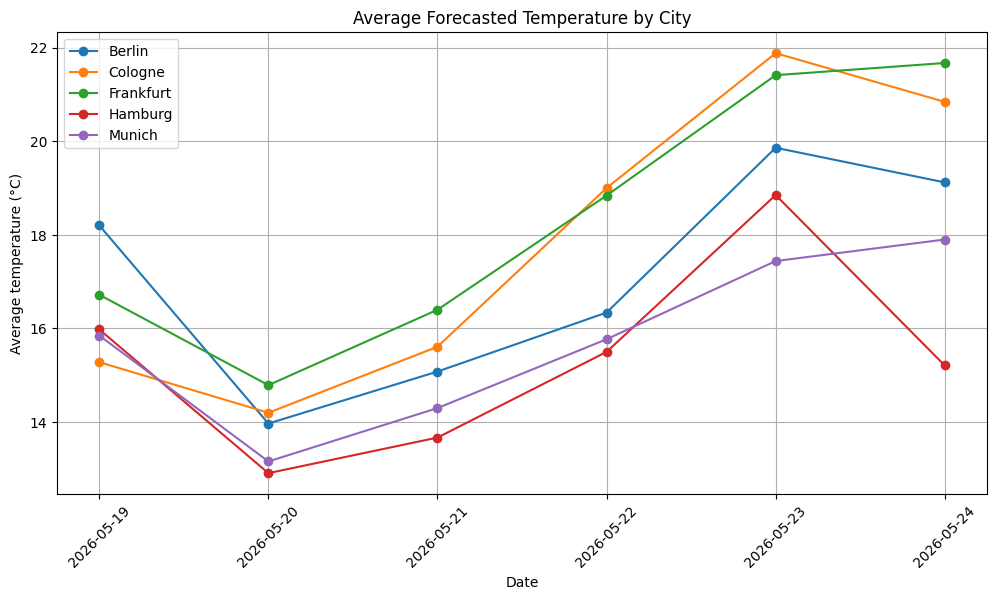

In [8]:
if not df_daily_weather.empty:
    plt.figure(figsize=(12, 6))

    for city in df_daily_weather["city"].unique():
        data = df_daily_weather[df_daily_weather["city"] == city]
        plt.plot(data["date"], data["avg_temp"], marker="o", label=city)

    plt.title("Average Forecasted Temperature by City")
    plt.xlabel("Date")
    plt.ylabel("Average temperature (°C)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No daily weather data to plot.")


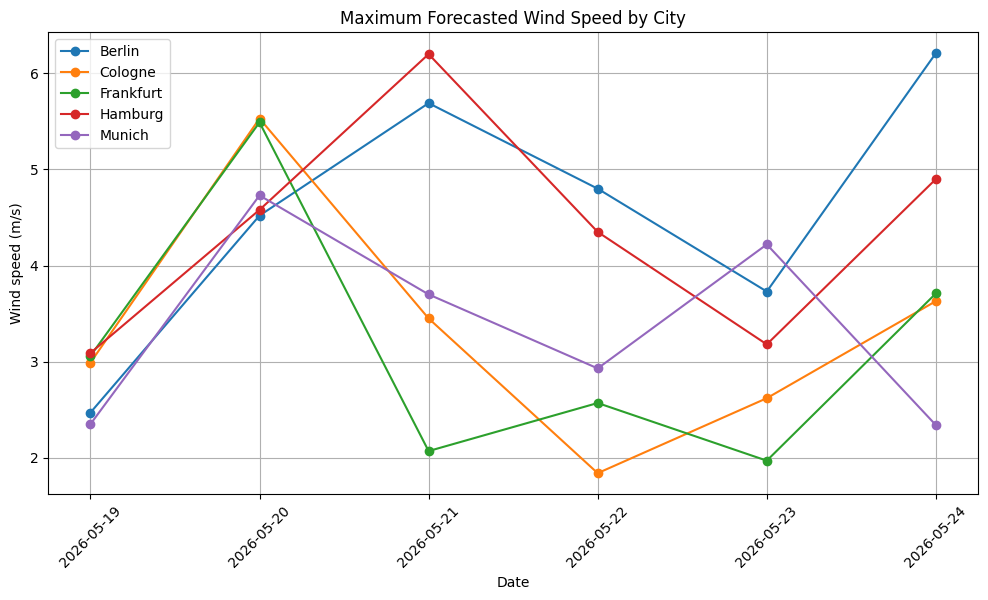

In [9]:
if not df_daily_weather.empty:
    plt.figure(figsize=(12, 6))

    for city in df_daily_weather["city"].unique():
        data = df_daily_weather[df_daily_weather["city"] == city]
        plt.plot(data["date"], data["max_wind_speed"], marker="o", label=city)

    plt.title("Maximum Forecasted Wind Speed by City")
    plt.xlabel("Date")
    plt.ylabel("Wind speed (m/s)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No daily weather data to plot.")


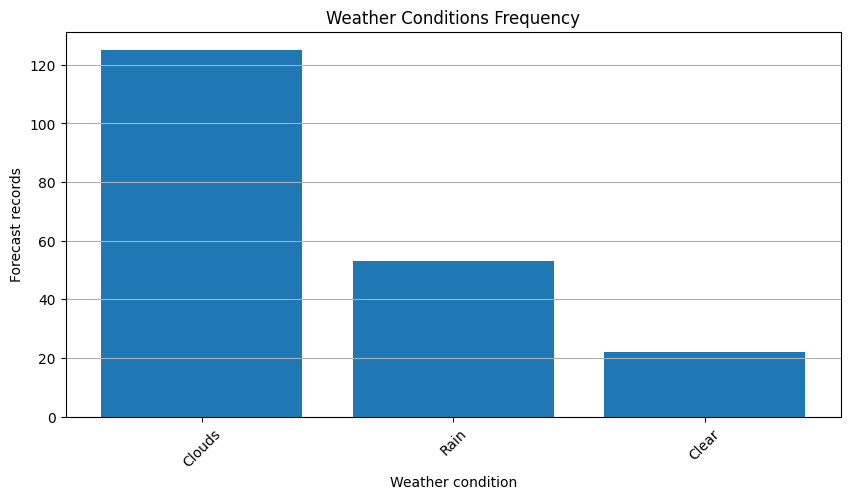

,weather_main,forecast_records
0,Clouds,125
1,Rain,53
2,Clear,22


In [10]:
if not df_forecast.empty:
    weather_counts = (
        df_forecast["weather_main"]
        .value_counts()
        .rename_axis("weather_main")
        .reset_index(name="forecast_records")
    )

    plt.figure(figsize=(10, 5))
    plt.bar(weather_counts["weather_main"], weather_counts["forecast_records"])
    plt.title("Weather Conditions Frequency")
    plt.xlabel("Weather condition")
    plt.ylabel("Forecast records")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

    display(weather_counts)
else:
    print("No forecast data to analyze.")


## 10. Export results

In [11]:
cities_path = OUTPUT_DIR / "weather_geocoded_cities.csv"
forecast_path = OUTPUT_DIR / "weather_forecast_3h.csv"
current_path = OUTPUT_DIR / "weather_current_nearest.csv"
daily_path = OUTPUT_DIR / "weather_daily_summary.csv"
api_log_path = OUTPUT_DIR / "weather_api_call_log.csv"
metadata_path = OUTPUT_DIR / "metadata.json"

df_cities.to_csv(cities_path, index=False)
df_forecast.to_csv(forecast_path, index=False)
df_current_like.to_csv(current_path, index=False)
df_daily_weather.to_csv(daily_path, index=False)
df_weather_api_log.to_csv(api_log_path, index=False)

metadata = {
    "run_timestamp_utc": datetime.utcnow().isoformat(),
    "cities": CITIES,
    "country_code": COUNTRY_CODE,
    "units": UNITS,
    "language": LANGUAGE,
    "rows": {
        "cities": int(len(df_cities)),
        "forecast": int(len(df_forecast)),
        "daily_summary": int(len(df_daily_weather)),
        "api_calls": int(len(df_weather_api_log)),
    },
    "output_files": [
        str(cities_path),
        str(forecast_path),
        str(current_path),
        str(daily_path),
        str(api_log_path),
    ],
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved files:")
for path in [cities_path, forecast_path, current_path, daily_path, api_log_path, metadata_path]:
    print(path)


Saved files:
outputs_weather/weather_geocoded_cities.csv
outputs_weather/weather_forecast_3h.csv
outputs_weather/weather_current_nearest.csv
outputs_weather/weather_daily_summary.csv
outputs_weather/weather_api_call_log.csv
outputs_weather/metadata.json


/tmp/ipykernel_1669/1492915125.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_timestamp_utc": datetime.utcnow().isoformat(),


## 11. Optional database loading

The original workflow loaded weather data into a local MySQL database.

This GitHub version exports CSV files instead.

For production-style workflows, load the CSV files into a database using a separate private script with credentials stored in environment variables.


## 12. Limitations

- The notebook requires an OpenWeather API key.
- Free API plans may have rate limits.
- Forecast data is time-sensitive.
- The forecast endpoint returns 3-hour intervals, not true real-time current weather.
- City names can be ambiguous, so `COUNTRY_CODE` is used.
- This is a data collection and analysis prototype, not a production ETL pipeline.
